# **EQ01 : Heston : revue du modèle et cohérence de calibration**

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

from JR_PRICER.curves.interpolators_1D.cubic_splines import ScipyCubicSplinesInterpolator1D

from JR_PRICER.instruments.derivatives.equity.european_option import EuropeanOption, OptionType
from JR_PRICER.pricing.engine.fourier_carr_madan import FourierCarrMadanEngine
from JR_PRICER.pricing.implied_vol_calculator import ImpliedVolCalculator
from JR_PRICER.pricing.model.heston import HestonModel

from JR_PRICER.calibration.calibrate import calibrate
from JR_PRICER.calibration.cost_function.model.implied_vol_cost import ImpliedVolErrorCost
from JR_PRICER.calibration.cost_function.model.price_error_cost import PriceErrorCost
from JR_PRICER.calibration.optimizer.least_squares import SciPyOLSOptimizer

from JR_PRICER.pricing.model.discretization.CIR.base import CIRDiscretizationSchemeEuler
from JR_PRICER.pricing.model.discretization.CIR.base import EulerDiscretizationConvention
from JR_PRICER.pricing.engine.monte_carlo import MCEngine, MCPaths


from JR_PRICER.surfaces.vol_surface.volsurface import VolSurface
from JR_PRICER.surfaces.vol_surface.interpolators_2D.bi_cubic import BiCubicInterpolator
from JR_PRICER.surfaces.vol_surface.interpolators_2D.SVI import SVIInterpolator

from JR_PRICER.market_data.quote import Quote
from JR_PRICER.instruments.derivatives.equity.base import Underlying
from JR_PRICER.curves.vol_smile.volsmile import VolSmile
from JR_PRICER.curves.vol_smile.moneyness_convention import LogMoneynessForward, LogMoneynessSpot, SimpleMoneyness, AbsoluteStrike
from JR_PRICER.curves.forward.analytic_forward import AnalyticForwardCurve
from JR_PRICER.curves.temporal.discount import FlatDiscountCurve
from JR_PRICER.utils.day_count import DayCounter

from JR_PRICER.viz.surfaces import plot_surface
from JR_PRICER.viz.mc import plot_paths,plot_distribution

## **1. Présentation du modèle**

Dans ce notebook, nous allons couvrir le modèle de Heston. Ce modèle peut être vu comme une évolution du modèle de Black-Scholes : Heston ajoute une dimension de **volatilité stochastique**.

Cette évolution permet d'expliquer des phénomènes comme le smile de volatilité ainsi que sa dynamique.

Voici la dynamique du sous-jacent sous Heston : 

$$
\begin{aligned}
dS_t &= \mu S_t dt + \sqrt{v_t}\,S_t\,dW_t^S,\\
dv_t &= \kappa(\theta - v_t)\,dt + \sigma_v\sqrt{v_t}\,dW_t^v,\qquad
d\langle W^S, W^v\rangle_t = \rho\,dt.
\end{aligned}
$$

Autrement dit, c'est la **variance** $v_t$ (et donc la volatilité $\sqrt{v_t}$) qui est elle-même stochastique : elle retourne vers sa moyenne long terme $\theta$ à la vitesse $\kappa$, et ses propres chocs sont corrélés à ceux du sous-jacent via $\rho$.

Les paramètres du modèle :

| Paramètre | Signification |
|---|---|
| $\theta$ | variance moyenne long terme |
| $\kappa$ | vitesse de retour à la moyenne $\theta$ |
| $\sigma_v$ | vol-of-vol (« volatilité de la variance ») |
| $\rho$ | corrélation entre les chocs du sous-jacent et de la variance |
| $v_0$ | variance initiale (point de départ) |


### **1.1 La surface de volatilité impliquée par Heston**

Le modèle de Heston implique une certaine dynamique, et celle-ci implique une certaine forme pour la surface de volatilité. Pour visualiser ce phénomène, on se donne des calls européens couvrant une surface :
$$K \in [S - a, S + a] \quad\times\quad T \in [0, T_{max}]$$
(des strikes autour du spot, pour des maturités jusqu'à $T_{max}$).
On price ensuite ces calls sous Heston (paramètres choisis à la main) par Fourier/Carr-Madan — donc sans biais de pricing, formule quasi-analytique — puis on inverse leur prix en volatilité implicite Black-Scholes. On obtient ainsi une **surface de volatilité implicite**.

On suppose un sous-jacent avec une courbe forward à dividende nul et une courbe de discount à $r = 0.04$.

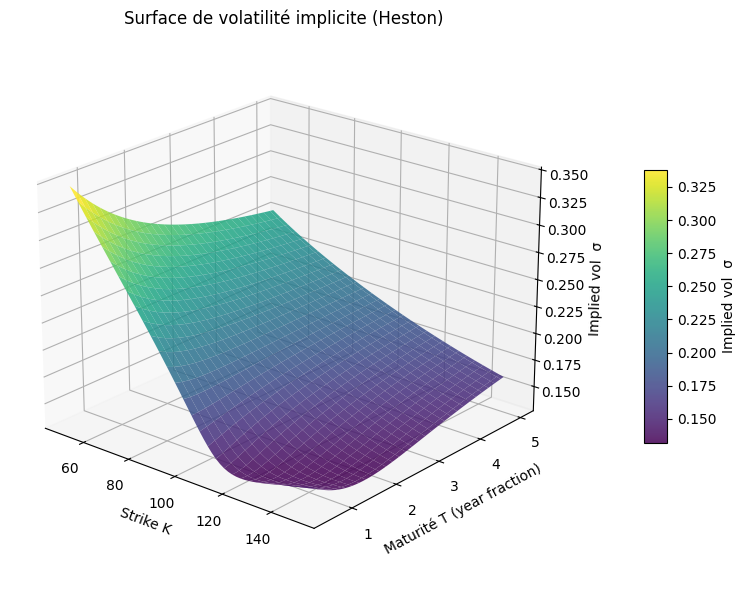

In [73]:
# Paramètres de marché :
ref_date = date(2025, 1, 1)
day_count_convention_act365 = DayCounter(convention='act/365')
unique_discount_curve = FlatDiscountCurve(
    flat_rate=0.04,
    day_count_convention=day_count_convention_act365,
    reference_date=ref_date
)

# Paramètres de la surface d'options que l'on veut générer
spot = 100
a = 50
density_K = 100
density_T = 50
T_max = 5

# Paramétrisation d'un Heston choisi à la main (pour illustrer,
# même si les paramètres sont assez réalistes) :
example_heston = HestonModel(
    kappa=1.5,
    theta=0.04,
    sigma_v=0.5,
    rho=-0.7,
    v0=0.035,
    discount_curve=unique_discount_curve
)

# Génération de la surface d'options :
K_range = np.linspace(spot - a, spot + a, density_K)
T_range = np.linspace(0.5, T_max, density_T)
T_range_dates = [day_count_convention_act365.to_date(ref_date, T) for T in T_range]

common_underlying = Underlying(
    name="Stock ABC",
    spot=Quote(value=spot),
    forward_curve=AnalyticForwardCurve(
        spot=Quote(value=spot),
        discount_curve=unique_discount_curve,
        dividend_yield=0.0
    )
)

options_list_of_lists = []
for T in T_range_dates:
    options_by_maturity = [
        EuropeanOption(
            underlying=common_underlying,
            maturity_date=T,
            K=K,
            start_date=ref_date,
            option_type=OptionType.CALL,
            notional=1
        ) for K in K_range
    ]
    options_list_of_lists.append(options_by_maturity)

# Pricing par Heston :
fourier_engine = FourierCarrMadanEngine(n=12, alpha=1.5)
ivc = ImpliedVolCalculator(unique_discount_curve)

implied_vols, prices_all = [], []
for options_list in options_list_of_lists:
    prices = fourier_engine.price(options_list, example_heston)
    prices_all.append(prices)
    implied_vols_by_maturity = ivc.calculate_implied_vol(options_list, prices)
    implied_vols.append(implied_vols_by_maturity)

# On range les vols implicites dans un objet VolSurface (un smile par maturité,
# en strike absolu) plutôt que de manipuler une grille à la main. La grille étant
# déjà dense, l'interpolateur bicubique reproduit fidèlement la surface Heston.
heston_smiles = [
    VolSmile(strikes=K_range,
             volatilities=implied_vols[i],
             interpolator=ScipyCubicSplinesInterpolator1D(),
             maturity=T_range_dates[i],
             moneyness_convention=AbsoluteStrike())
    for i in range(density_T)
]
heston_surface = VolSurface(
    smiles=heston_smiles,
    reference_date=ref_date,
    day_count_convention=day_count_convention_act365,
    interpolator=BiCubicInterpolator(),
    forward_curve=common_underlying.forward_curve
)
heston_surface.calibrate_interpolator()

# Tracé 3D via l'objet surface (l'axe X suit automatiquement la convention de moneyness).
ax = plot_surface(heston_surface, with_interpolation=True, show_pillars=False)
ax.set_title('Surface de volatilité implicite (Heston)')
ax.view_init(elev=22, azim=-50)
plt.tight_layout()
plt.show()


In [74]:
# Helper réutilisé plus bas : smile de vol implicite Heston à une maturité donnée.
# On price les calls par Fourier puis on inverse en vol implicite Black-Scholes (ivc).
def heston_iv(model, maturity_date, strikes):
    """Vols implicites BS du modèle Heston aux strikes donnés, pour une maturité fixe."""
    calls = [EuropeanOption(underlying=common_underlying, K=float(K), start_date=ref_date,
                            maturity_date=maturity_date, option_type=OptionType.CALL, notional=1)
             for K in strikes]
    return ivc.calculate_implied_vol(calls, fourier_engine.price(calls, model))


### **1.2 Exploration des paramètres du modèle**

Le but de cette sous-section va être d'explorer les paramètres et leur propriétés.

#### **Le processus CIR (la dynamique de la variance)**

Le processus CIR (Cox-Ingersoll-Ross) est le processus stochastique qui guide la variance dans le modèle de Heston :

$$
dv_t = \kappa(\theta - v_t)\,dt + \sigma_v \sqrt{v_t}\,dW_t^v
$$

Il a des propriétés qui le rendent réaliste pour une variance :
- **mean-reverting** : une force de rappel ramène la variance vers sa valeur long terme $\theta$, à la vitesse $\kappa$ ;
- **positif** : en temps continu la variance reste toujours $\ge 0$ ; et si la condition de Feller $2\kappa\theta \ge \sigma_v^2$ est vérifiée, elle reste même strictement $> 0$ (elle ne touche jamais 0). En pratique, selon le schéma de discrétisation, cette positivité peut être violée (cf. 1.2.6) ;
- **volatil** : la variance a sa propre volatilité $\sigma_v$ (la « vol-of-vol »).

Nous allons simuler ce processus pour observer la variance de Heston et sa dynamique selon les paramètres.

*Note : ici le schéma de discrétisation est Euler « full-truncation ». Il n'est pas optimal numériquement ; l'ajout d'autres schémas est l'objet d'une future mise à jour du package.*

#### **1.2.1 La moyenne : $\theta$**

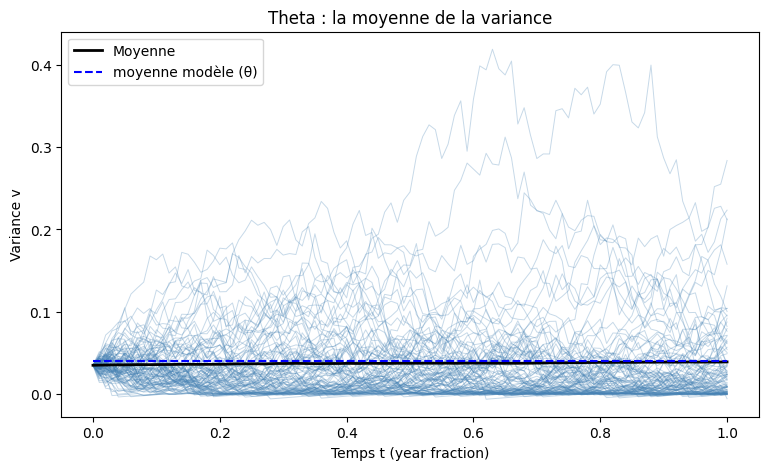

In [75]:
# Instanciation d'un produit quelconque 
# (on va le pricer par monte Carlo et récupérer les chemins du processus CIR): 
dummy_product = EuropeanOption(
            underlying=common_underlying,
            maturity_date=date(2026,1,1),
            K=100,
            start_date=ref_date,
            option_type=OptionType.CALL,
            notional=1
)

#on réutilise le modèle Heston vu plus tôt en le discrétisant : 
discretized_heston = example_heston.discretize(scheme = CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION),
                          max_dt=0.01)
example_mc_engine = MCEngine(10000, 123)
result = example_mc_engine.simulate_paths(dummy_product,discretized_heston)

#On plot la variance : 
plot_paths(result= result, quantity="variance", show_mean= True)
plt.title("Theta : la moyenne de la variance")
plt.hlines(y=discretized_heston.theta,xmin=0, xmax=1, linestyles= "dashed",colors="b", label= "moyenne modèle (θ)")
plt.legend()
plt.show()


On voit que, comme prévu, la **variance moyenne** part de $v_0$ puis converge vers la valeur théorique $\theta$ : c'est précisément le rôle de $\theta$, le niveau long terme vers lequel la variance est rappelée.

#### **1.2.2 La vitesse de retour à la moyenne : $\kappa$**

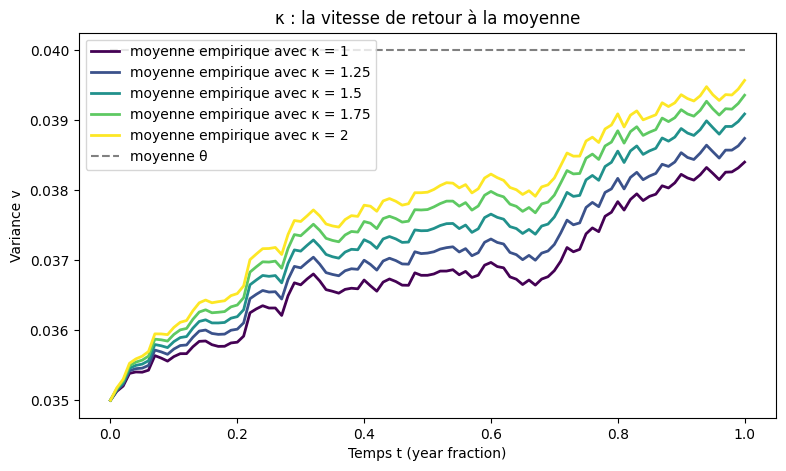

In [76]:
# On crée 5 modèles de Heston avec un kappa (vitesse de retour à la moyenne) différent :
kappas = [1, 1.25, 1.5, 1.75, 2]
kappa_heston_models = [HestonModel(
    kappa=kap,
    theta=0.04,
    sigma_v=0.5,
    rho=-0.7,
    v0=0.035,
    discount_curve=unique_discount_curve) for kap in kappas]

# On superpose la variance MOYENNE de chaque modèle sur LE MÊME axe (ax partagé),
# une couleur par kappa via une colormap. n_paths_shown=0 -> seule la moyenne est
# tracée (sinon 5 nuages de trajectoires se chevaucheraient et masqueraient l'effet).
# Lecture : plus kappa est grand, plus vite la variance revient vers theta.
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("viridis")

for kap, model in zip(kappas, kappa_heston_models):
    discretized_heston = model.discretize(
        scheme=CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION),
        max_dt=0.01)
    result = MCEngine(10000, 123).simulate_paths(dummy_product, discretized_heston)
    color = cmap((kap - kappas[0]) / (kappas[-1] - kappas[0]))
    plot_paths(result, ax=ax, quantity="variance", n_paths_shown=0,
               show_mean=True, color=color, label=f"moyenne empirique avec κ = {kap}")

ax.hlines(y=kappa_heston_models[0].theta, xmin=0, xmax=1,
          linestyles="dashed", colors="grey", label="moyenne θ")
ax.set_title("κ : la vitesse de retour à la moyenne")
ax.legend()
plt.show()


On s'aperçoit que la moyenne empirique s'approche de theta plus rapidement selon la valeur de $\kappa$. C'est à cela que le terme sert : c'est un terme de retour vers la variance long terme $\theta$.

#### **1.2.3 : la variance de la variance (ou vol-of-vol) $\sigma_v$**

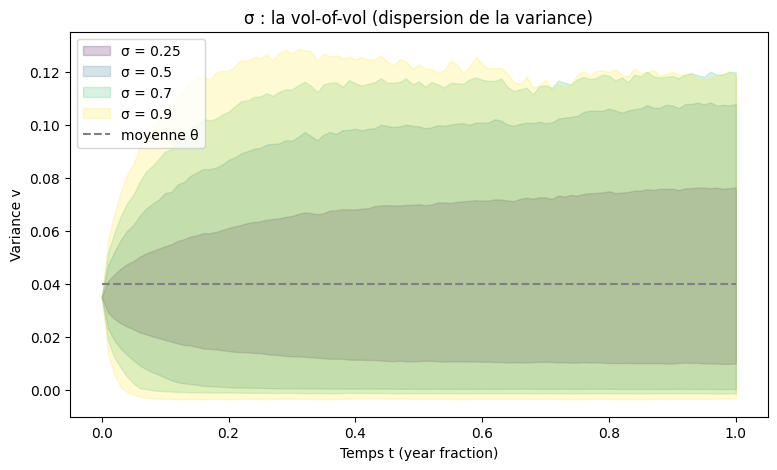

In [77]:
# On crée 4 modèles de Heston avec une vol-of-vol (sigma_v) différente :
sigma_vs = [0.25, 0.5, 0.7, 0.9]
sigma_heston_models = [HestonModel(
    kappa=1.5,
    theta=0.04,
    sigma_v=sig,
    rho=-0.7,
    v0=0.035,
    discount_curve=unique_discount_curve) for sig in sigma_vs]

# sigma_v ne change PAS la variance moyenne (identique pour tous), mais sa DISPERSION.
# On superpose donc la bande inter-quantiles (10%-90%) de chaque sigma_v sur LE MÊME axe
# (n_paths_shown=0, show_mean=False) : plus sigma_v est grand, plus la bande est large.
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("viridis")

for sig, model in zip(sigma_vs, sigma_heston_models):
    discretized_heston = model.discretize(
        scheme=CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION),
        max_dt=0.01)
    result = MCEngine(10000, 123).simulate_paths(dummy_product, discretized_heston)
    color = cmap((sig - sigma_vs[0]) / (sigma_vs[-1] - sigma_vs[0]))
    plot_paths(result, ax=ax, quantity="variance", n_paths_shown=0,
               show_mean=False, color=color, quantiles=(0.1, 0.9), label=f"σ = {sig}")

ax.hlines(y=sigma_heston_models[0].theta, xmin=0, xmax=1,
          linestyles="dashed", colors="grey", label="moyenne θ")
ax.set_title("σ : la vol-of-vol (dispersion de la variance)")
ax.legend()
plt.show()


$\sigma_v$ contrôle la **dispersion** de la variance (la largeur de la bande de quantiles), mais **pas sa moyenne**. C'est pourquoi on trace ici les quantiles plutôt que la moyenne. Une vol-of-vol plus forte ⇒ une variance plus erratique ⇒ des queues plus épaisses dans la distribution du sous-jacent, donc un smile plus **bombé** (convexité). On le retrouvera sur la distribution terminale en 1.3.

#### **1.2.4 : la corrélation sous-jaçent / variance : $\rho$**

C'est ce paramètre qui va largement influencer le **skew**. En effet, $\rho$ corrèle les chocs du sous-jacent et ceux de sa variance. Avec $\rho < 0$ (cas habituel des actions, l'« effet de levier »), une baisse du sous-jacent s'accompagne en moyenne d'une **hausse** de la variance : la queue de gauche s'épaissit, les puts de bas strike deviennent plus chers, et le smile penche vers le bas (skew négatif). Inversement, $\rho > 0$ relève l'aile droite. À $\rho = 0$, le smile est quasi symétrique (la convexité restante venant de $\sigma_v$).

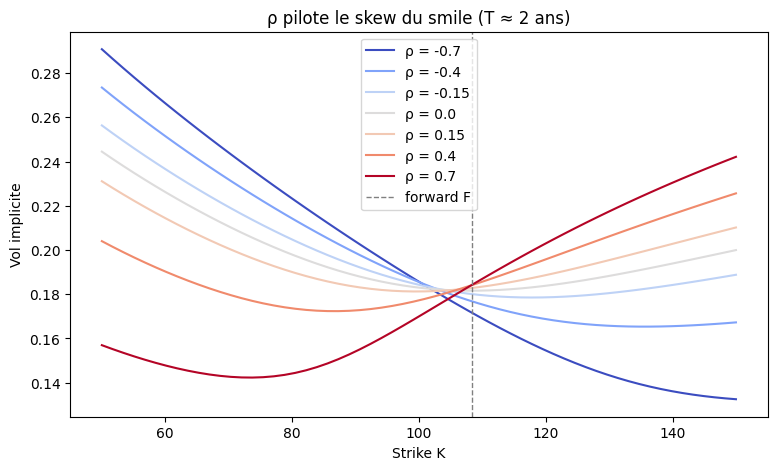

In [78]:
# ρ pilote le SKEW. On superpose le smile de vol implicite (à maturité fixe) pour
# plusieurs ρ — bien plus lisible que des surfaces 3D séparées pour comparer le skew.
rhos = [-0.7, -0.4, -0.15, 0.0, 0.15, 0.4, 0.7]
maturity = date(2027, 1, 1)                  # ~2 ans : skew bien marqué
T = day_count_convention_act365.year_fraction(ref_date, maturity)
F = common_underlying.forward_curve.forward(T)
strikes_smile = np.linspace(spot - a, spot + a, 60)

fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("coolwarm")
for rho in rhos:
    model = HestonModel(kappa=1.5, theta=0.04, sigma_v=0.5, rho=rho, v0=0.035,
                        discount_curve=unique_discount_curve)
    iv = heston_iv(model, maturity, strikes_smile)
    color = cmap((rho - rhos[0]) / (rhos[-1] - rhos[0]))
    ax.plot(strikes_smile, iv, color=color, label=f"ρ = {rho}")

ax.axvline(F, color="grey", linestyle="dashed", linewidth=1, label="forward F")
ax.set_xlabel("Strike K"); ax.set_ylabel("Vol implicite")
ax.set_title("ρ pilote le skew du smile (T ≈ 2 ans)")
ax.legend()
plt.show()


On observe bien la **rotation du smile** avec $\rho$ : à bas strike la vol implicite est plus élevée pour $\rho < 0$ (skew baissier) et plus basse pour $\rho > 0$, le cas $\rho = 0$ donnant un sourire presque symétrique. C'est le levier principal pour reproduire le skew des marchés actions. Noter que $\rho$ déforme le smile **sans changer la dynamique de la variance** vue plus haut : il agit via la corrélation spot/variance, pas via le processus CIR lui-même.

#### **1.2.5 : la variance initiale $v_0$**

$v_0$ fixe le point de départ de la variance. Le processus part de $v_0$ puis est ramené vers $\theta$ à la vitesse $\kappa$ : $v_0$ pilote donc surtout le **court terme** (la vol implicite des courtes maturités), avant que la structure par terme ne converge vers $\theta$.

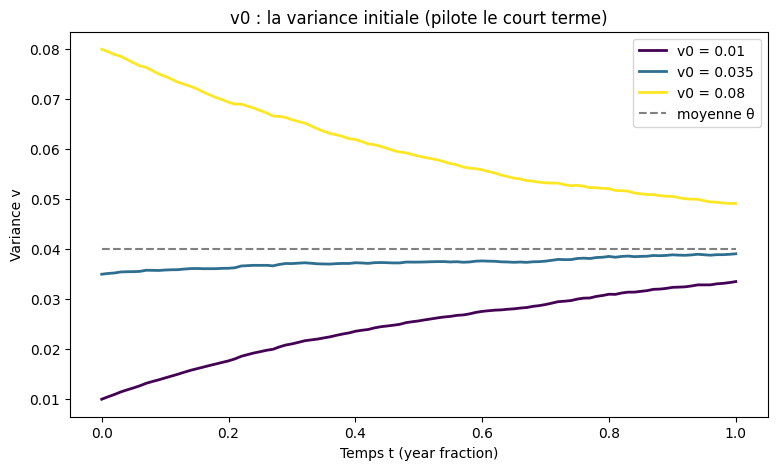

In [79]:
# On crée 3 modèles avec une variance initiale v0 différente (theta=0.04 fixe).
# Même motif que kappa : on superpose la variance MOYENNE, une couleur par v0.
v0s = [0.01, 0.035, 0.08]
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("viridis")

for v0 in v0s:
    model = HestonModel(kappa=1.5, theta=0.04, sigma_v=0.5, rho=-0.7, v0=v0,
                        discount_curve=unique_discount_curve)
    discretized = model.discretize(
        scheme=CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION),
        max_dt=0.01)
    result = MCEngine(10000, 123).simulate_paths(dummy_product, discretized)
    color = cmap((v0 - v0s[0]) / (v0s[-1] - v0s[0]))
    plot_paths(result, ax=ax, quantity="variance", n_paths_shown=0,
               show_mean=True, color=color, label=f"v0 = {v0}")

ax.hlines(y=0.04, xmin=0, xmax=1, linestyles="dashed", colors="grey", label="moyenne θ")
ax.set_title("v0 : la variance initiale (pilote le court terme)")
ax.legend()
plt.show()


La variance moyenne **part bien de $v_0$** puis rejoint $\theta$ : seules les premières dates (le court terme) distinguent les trois modèles. Sur la surface de vol, $v_0$ agit donc surtout sur le niveau des **courtes maturités**, tandis que $\theta$ fixe le niveau long terme.

#### **1.2.6 : Condition de Feller & schémas de discrétisation**

La condition de Feller $2\kappa\theta \ge \sigma_v^2$ garantit que la variance reste **strictement positive** en temps continu. Quand elle est violée (forte vol-of-vol), la variance peut atteindre 0, et le schéma de discrétisation doit décider quoi faire d'une variance qui voudrait devenir négative. On compare ici les trois conventions Euler — *absorption*, *réflexion*, *full-truncation* — sur un cas qui viole Feller, et on mesure la fraction de trajectoires qui touchent 0.

Ratio de Feller  2κθ/σ_v² = 0.148  ->  VIOLÉE


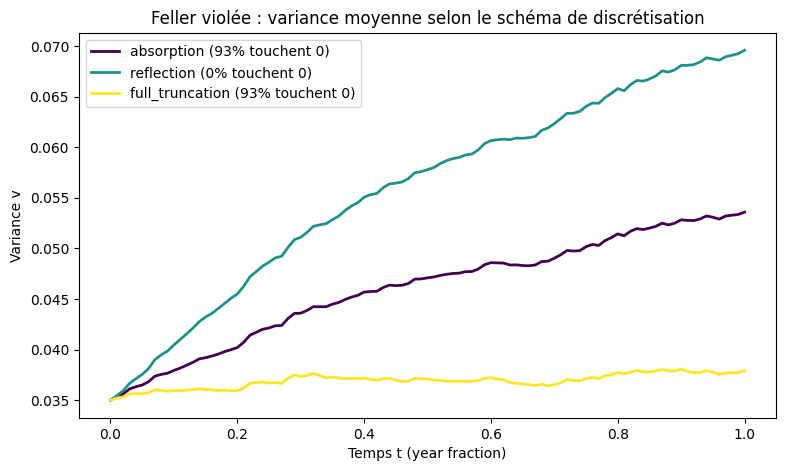

In [80]:
# Cas qui VIOLE Feller : 2*kappa*theta < sigma_v**2 (forte vol-of-vol).
kappa, theta, sigma_v = 1.5, 0.04, 0.9
feller = 2 * kappa * theta / sigma_v**2
print(f"Ratio de Feller  2κθ/σ_v² = {feller:.3f}  ->  {'OK' if feller >= 1 else 'VIOLÉE'}")

feller_heston = HestonModel(kappa=kappa, theta=theta, sigma_v=sigma_v, rho=-0.7, v0=0.035,
                            discount_curve=unique_discount_curve)

# On compare les 3 conventions Euler : variance moyenne + fraction de trajectoires
# qui touchent 0 (la condition de Feller violée rend ce comportement fréquent).
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("viridis")
conventions = list(EulerDiscretizationConvention)
for i, conv in enumerate(conventions):
    model = feller_heston.discretize(scheme=CIRDiscretizationSchemeEuler(conv), max_dt=0.01)
    result = MCEngine(10000, 123).simulate_paths(dummy_product, model)
    frac_zero = (result.variance_paths <= 1e-8).any(axis=1).mean()
    color = cmap(i / (len(conventions) - 1))
    plot_paths(result, ax=ax, quantity="variance", n_paths_shown=0, show_mean=True,
               color=color, label=f"{conv.value} ({frac_zero:.0%} touchent 0)")

ax.set_title("Feller violée : variance moyenne selon le schéma de discrétisation")
ax.legend()
plt.show()


Feller étant violée ici ($2\kappa\theta/\sigma_v^2 \approx 0.15$), une grande partie des trajectoires atteint 0. Les trois schémas gèrent différemment cette variance qui voudrait devenir négative : *absorption* la colle à 0, *full-truncation* la laisse passer en négatif (mais utilise $\max(v,0)$ dans la diffusion), *reflection* la renvoie dans le positif (et ne touche donc jamais 0). Résultat : des **variances moyennes légèrement différentes** selon le schéma : c'est un biais de discrétisation, pas une propriété du modèle continu. On le réduit en raffinant le pas (`max_dt`) ou avec un schéma plus fin (ex. Andersen QE).

### **1.3 Distribution terminale du sous-jacent**

La volatilité stochastique combinée à la corrélation $\rho < 0$ déforme la distribution du sous-jacent par rapport à la lognormale de Black-Scholes : **queues plus épaisses** (kurtosis) et **asymétrie** (skew vers la gauche pour $\rho<0$). C'est l'autre face du smile. On compare ci-dessous la distribution terminale simulée sous Heston à une lognormale de même volatilité ATM.

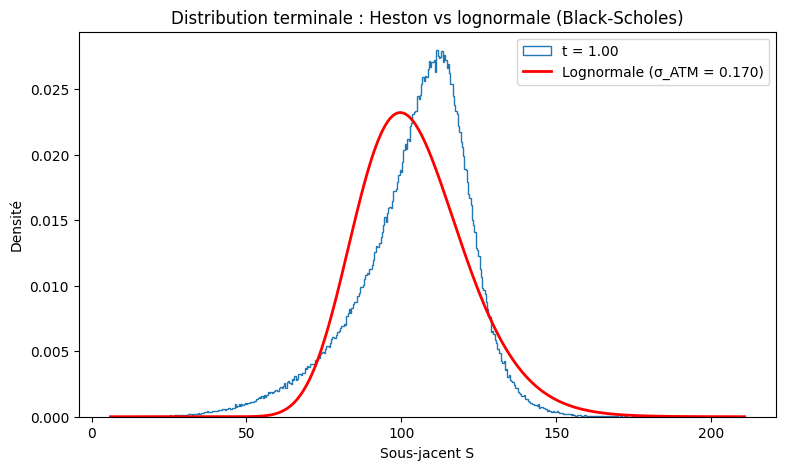

In [81]:
# Distribution terminale S_T sous Heston (MC) vs lognormale de même vol ATM.
res_T = MCEngine(500000, 123).simulate_paths(
    dummy_product,
    example_heston.discretize(
        scheme=CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION),
        max_dt=0.01))

T = res_T.times[-1]
F = common_underlying.forward_curve.forward(T)
sigma_atm = float(heston_iv(example_heston, dummy_product.maturity_date, [F])[0])  # vol ATM Heston

ax = plot_distribution(res_T, steps=[-1], bins=500)

# Densité lognormale de référence (mesure forward, même vol ATM Heston) :
mu = np.log(F) - 0.5 * sigma_atm**2 * T
s = sigma_atm * np.sqrt(T)
xs = np.linspace(res_T.terminal_spot.min(), res_T.terminal_spot.max(), 400)
pdf = np.exp(-(np.log(xs) - mu)**2 / (2 * s**2)) / (xs * s * np.sqrt(2 * np.pi))
ax.plot(xs, pdf, "r-", lw=2, label=f"Lognormale (σ_ATM = {sigma_atm:.3f})")
ax.set_title("Distribution terminale : Heston vs lognormale (Black-Scholes)")
ax.legend()
plt.show()


La distribution simulée sous Heston est **plus piquée** au centre, à **queues plus épaisses** et **asymétrique** par rapport à la lognormale de même vol ATM ($\rho<0$ déplace de la masse vers la queue de gauche). Ce sont exactement ces écarts qui créent le smile : queues épaisses ⇒ ailes du smile relevées (convexité, via $\sigma_v$), asymétrie ⇒ skew (via $\rho$). **Distribution terminale et smile sont deux lectures du même phénomène** — c'est tout l'intérêt de Heston par rapport à Black-Scholes, dont la distribution lognormale ne peut produire qu'un smile plat.

# **2. La calibration du modèle de Heston**

Maintenant que nous avons la(les) surfaces 'objectif' interpolées. On peut maintenant essayer de calibrer un modèle aveugle qui n'a pas conaissance des réels paramètres Heston que l'on a utilisé pour générer la surface : 

In [82]:
# --- Sous-échantillonnage de la grille de calibration ----------------------
# 5 paramètres Heston ne nécessitent pas 5000 quotes (système très surdéterminé).
# On calibre sur ~120 points bien répartis
# NB : la surface 3D (cellule 1.1) reste, elle, sur la grille complète.
T_idx = np.unique(np.linspace(0, density_T - 1, 10).astype(int))
K_idx = np.unique(np.linspace(0, density_K - 1, 12).astype(int))

options_flat      = [options_list_of_lists[i][j] for i in T_idx for j in K_idx]
implied_vols_flat = [implied_vols[i][j]          for i in T_idx for j in K_idx]
prices_flat       = [prices_all[i][j]            for i in T_idx for j in K_idx]

# Calibration : départ volontairement éloigné de la vérité
theta0 = np.array([1.0, 0.05, 0.40, -0.30, 0.04])     # kappa, theta, sigma_v, rho, v0
# Bornes au format canonique [(lo, hi), ...] (une paire par paramètre).
bounds = [(0.05, 10.0), (0.005, 0.50), (0.05, 2.00), (-0.999, 0.999), (0.005, 0.50)]  # kappa, theta, sigma_v, rho, v0

# Fonctions de coût disponibles (le coeur de la calibration) :
cost_functions = [
    ImpliedVolErrorCost(
        instruments=options_flat,
        market_implied_vols=implied_vols_flat,
        engine=fourier_engine,
        discount_curve=unique_discount_curve,
        model_class=HestonModel
    ),
    PriceErrorCost(
        instruments=options_flat,
        market_prices=prices_flat,
        engine=fourier_engine,
        discount_curve=unique_discount_curve,
        model_class=HestonModel
    )
]

# verbose=2 -> on voit les itérations défiler (preuve que ce n'est pas figé)
optimizer = SciPyOLSOptimizer(options={'verbose': 2})

# Calibration des modèles
calibrated_models = [calibrate(optimizer=optimizer,
                               cost_function=cf,
                               theta_0=theta0,
                               bounds=bounds) for cf in cost_functions]

# Comparaison aux vrais paramètres ayant servi à générer la surface :
truth = np.array([example_heston.kappa, example_heston.theta, example_heston.sigma_v,
                  example_heston.rho, example_heston.v0])
print(f"{'Vrais paramètres':22s} -> {np.round(truth, 4)}")
for cf, m in zip(cost_functions, calibrated_models):
    got = np.array([m.kappa, m.theta, m.sigma_v, m.rho, m.v0])
    print(f"{type(cf).__name__:22s} -> {np.round(got, 4)}  |err|={np.round(np.abs(got - truth), 4)}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.3925e-02                                    2.10e-01    
       1              2         5.0721e-03      4.89e-02       2.41e-01       2.39e-02    
       2              3         6.9408e-04      4.38e-03       4.71e-01       1.97e-01    
       3              4         4.3863e-06      6.90e-04       1.29e-01       1.03e-02    
       4              5         6.6947e-10      4.39e-06       5.81e-03       1.27e-05    
       5              6         3.9003e-17      6.69e-10       9.76e-05       1.48e-09    
`gtol` termination condition is satisfied.
Function evaluations 6, initial cost 5.3925e-02, final cost 3.9003e-17, first-order optimality 1.48e-09.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1306e+02                                    6.61e+02    
       1              2         4

On retombe bien sur les paramètres initiaux à la précision machine.

### **2.1 Qualité du fit : résidus marché vs modèle**

La surface ayant été générée par un Heston, la calibration retombe sur les paramètres exacts. On le vérifie en recalculant la vol implicite du **modèle calibré** sur la grille et en la comparant aux vols « marché » : les résidus doivent être négligeables (bruit numérique).

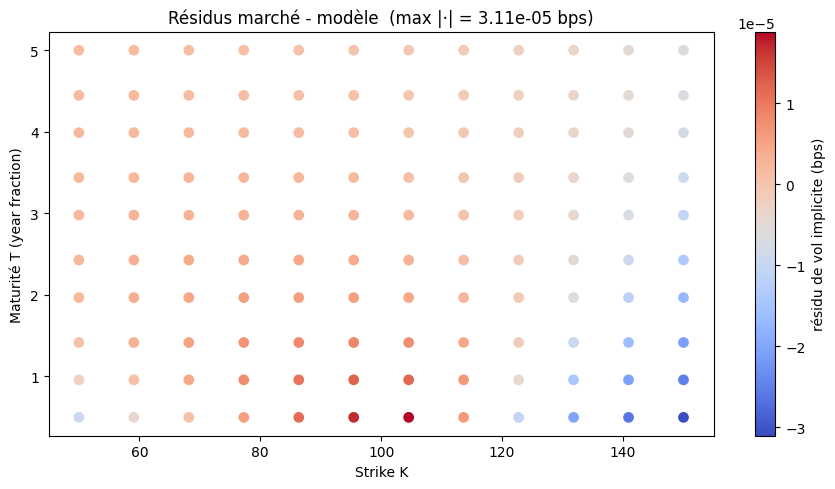

In [83]:
# Résidus de calibration : vol implicite (marché) - vol implicite (modèle calibré),
# sur la grille de calibration. Doit être ~0 puisque la surface vient d'un Heston.
calibrated_heston = calibrated_models[0]   # modèle calibré via ImpliedVolErrorCost

model_iv = ivc.calculate_implied_vol(options_flat, fourier_engine.price(options_flat, calibrated_heston))
residuals = np.asarray(implied_vols_flat) - np.asarray(model_iv)

strikes_flat = np.array([o.K for o in options_flat])
mats_flat = np.array([day_count_convention_act365.year_fraction(ref_date, o.maturity_date)
                      for o in options_flat])

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(strikes_flat, mats_flat, c=residuals * 1e4, cmap="coolwarm", s=45)
fig.colorbar(sc, ax=ax, label="résidu de vol implicite (bps)")
ax.set_xlabel("Strike K"); ax.set_ylabel("Maturité T (year fraction)")
ax.set_title(f"Résidus marché - modèle  (max |·| = {np.abs(residuals).max()*1e4:.2e} bps)")
plt.tight_layout(); plt.show()


### **2.2 Robustesse / identifiabilité**

On relance la calibration depuis plusieurs points de départ `theta_0` volontairement dispersés (mêmes bornes). Si l'optimum est bien identifié, tous convergent vers les mêmes paramètres — c'est le cas ici puisque la surface a été générée par un Heston. Sur des données de marché réelles, certains paramètres (notamment $\kappa$ et $\sigma_v$) sont souvent faiblement identifiables : plusieurs jeux donnent des surfaces quasi indistinguables.

In [84]:
# Robustesse : on relance la calibration (coût IV) depuis plusieurs départs theta_0
# volontairement dispersés, mêmes bornes. Tous convergent-ils vers le même optimum ?
cost_iv = cost_functions[0]   # ImpliedVolErrorCost
starts = [
    np.array([1.0, 0.05, 0.40, -0.30, 0.04]),
    np.array([3.0, 0.08, 0.80, -0.50, 0.06]),
    np.array([0.5, 0.02, 0.20,  0.20, 0.02]),
    np.array([5.0, 0.20, 1.50, -0.90, 0.10]),
]
silent = SciPyOLSOptimizer(options={'verbose': 0})

print(f"{'départ theta_0':40s} -> {'paramètres calibrés':42s} |err|max")
for th0 in starts:
    m = calibrate(optimizer=silent, cost_function=cost_iv, theta_0=th0, bounds=bounds)
    got = np.array([m.kappa, m.theta, m.sigma_v, m.rho, m.v0])
    print(f"{str(np.round(th0,3)):40s} -> {str(np.round(got,4)):42s} {np.max(np.abs(got-truth)):.2e}")


départ theta_0                           -> paramètres calibrés                        |err|max
[ 1.    0.05  0.4  -0.3   0.04]          -> [ 1.5    0.04   0.5   -0.7    0.035]       4.22e-08
[ 3.    0.08  0.8  -0.5   0.06]          -> [ 1.5    0.04   0.5   -0.7    0.035]       4.74e-12
[0.5  0.02 0.2  0.2  0.02]               -> [ 1.5    0.04   0.5   -0.7    0.035]       5.81e-11
[ 5.   0.2  1.5 -0.9  0.1]               -> [ 1.5    0.04   0.5   -0.7    0.035]       4.29e-09


# **3. Fourier vs Monte-Carlo : convergence et biais**

On a deux moteurs pour pricer sous Heston : **Fourier / Carr-Madan** (quasi-exact, via la fonction caractéristique) et **Monte-Carlo** (simulation des trajectoires). Le prix Fourier sert donc de **référence** pour étudier le MC : sa *convergence* (statistique, en $1/\sqrt{N}$) et son *biais de discrétisation* (dû au pas de temps et au schéma d'Euler sur le CIR).

On utilise `example_heston` (dont $\sigma_v = 0.5$ **viole Feller**, ce qui rend le biais bien visible) et un call ATM 1 an (`dummy_product`).

In [85]:
# Prix Fourier de référence (quasi-exact) du call ATM 1 an.
ref_call = dummy_product
px_fourier = fourier_engine.price([ref_call], example_heston)[0]
feller_ratio = 2 * example_heston.kappa * example_heston.theta / example_heston.sigma_v**2
print(f"Prix Fourier (référence) du call ATM 1 an : {px_fourier:.4f}")
print(f"Feller 2κθ/σ_v² = {feller_ratio:.3f}  ->  {'OK' if feller_ratio >= 1 else 'VIOLÉE (biais de discrétisation visible)'}")


Prix Fourier (référence) du call ATM 1 an : 9.1874
Feller 2κθ/σ_v² = 0.480  ->  VIOLÉE (biais de discrétisation visible)


### **3.1 Convergence du prix MC vers le prix Fourier**

À pas de temps fixé (fin) et schéma *full-truncation*, on fait croître le nombre de trajectoires $N$. Le prix MC oscille autour du prix Fourier dans un intervalle de confiance qui **rétrécit** à mesure que $N$ augmente.

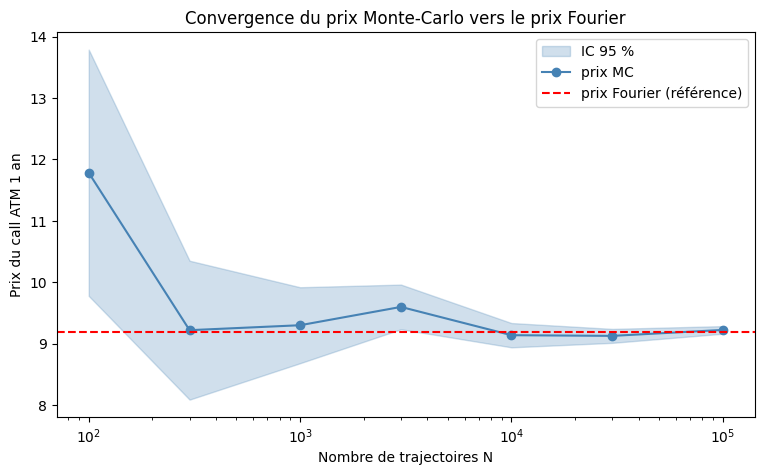

In [86]:
# Schéma + pas fixés (fins) ; on fait croître N.
fine_model = example_heston.discretize(
    CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION), max_dt=1/100)
Ns = np.array([100, 300, 1000, 3000, 10_000, 30_000, 100_000])

prices, ses = [], []
rng = np.random.default_rng(42)
for N in Ns:
    payoff = fine_model.simulate(ref_call, int(N), rng=rng)
    prices.append(payoff.mean())
    ses.append(payoff.std(ddof=1) / np.sqrt(N))
prices, ses = np.array(prices), np.array(ses)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(Ns, prices - 1.96*ses, prices + 1.96*ses, alpha=0.25, color="steelblue", label="IC 95 %")
ax.plot(Ns, prices, "o-", color="steelblue", label="prix MC")
ax.axhline(px_fourier, color="red", ls="--", label="prix Fourier (référence)")
ax.set_xscale("log")
ax.set_xlabel("Nombre de trajectoires N"); ax.set_ylabel("Prix du call ATM 1 an")
ax.set_title("Convergence du prix Monte-Carlo vers le prix Fourier")
ax.legend()
plt.show()


### **3.2 Vitesse de convergence : l'erreur en $1/\sqrt{N}$**

L'erreur *statistique* du Monte-Carlo (l'erreur-type $\mathrm{std}/\sqrt{N}$) décroît en $1/\sqrt{N}$ : en échelle log-log, c'est une droite de pente $-1/2$. Conséquence pratique : **diviser l'erreur par 10 coûte 100× plus de trajectoires**. On superpose l'écart réel $|MC - Fourier|$ : il suit l'erreur-type tant que le **biais de discrétisation** reste négligeable, puis plafonne sur ce biais.

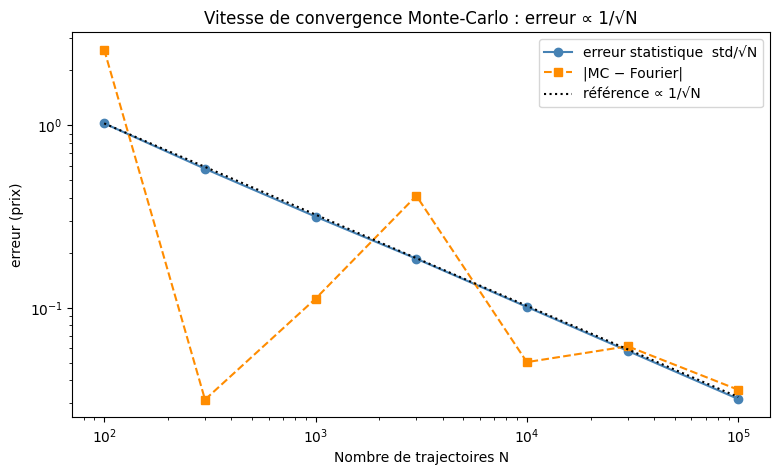

Pente log(erreur-type) vs log(N) = -0.502  (théorie : -0.5)


In [87]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(Ns, ses, "o-", color="steelblue", label="erreur statistique  std/√N")
ax.loglog(Ns, np.abs(prices - px_fourier), "s--", color="darkorange", label="|MC − Fourier|")
ax.loglog(Ns, ses[0] * np.sqrt(Ns[0] / Ns), "k:", label="référence ∝ 1/√N")
ax.set_xlabel("Nombre de trajectoires N"); ax.set_ylabel("erreur (prix)")
ax.set_title("Vitesse de convergence Monte-Carlo : erreur ∝ 1/√N")
ax.legend()
plt.show()

slope = np.polyfit(np.log(Ns), np.log(ses), 1)[0]
print(f"Pente log(erreur-type) vs log(N) = {slope:.3f}  (théorie : -0.5)")


### **3.3 Impact du pas de temps sur le biais**

Le MC discrétise le temps (schéma d'Euler), ce qui introduit un **biais** : le prix MC ne tend pas exactement vers le prix Fourier, mais vers une valeur décalée qui dépend du pas $\Delta t$. On fixe $N$ grand (bruit statistique faible) et on fait varier le pas : le biais $MC - Fourier$ **décroît vers 0** quand $\Delta t \to 0$ (biais d'Euler $\mathcal{O}(\Delta t)$).

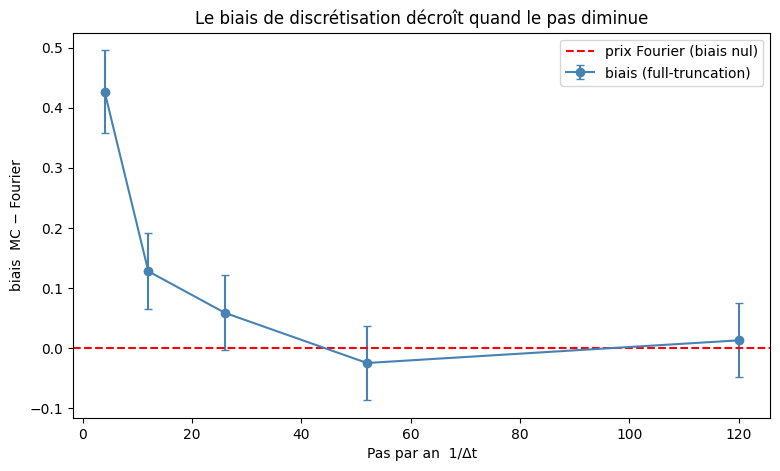

In [88]:
# Biais vs pas de temps (N grand pour réduire le bruit statistique), full-truncation.
N_bias = 100_000
dts = np.array([1/4, 1/12, 1/26, 1/52, 1/120])
ft = EulerDiscretizationConvention.FULL_TRUNCATION

bias, bias_se = [], []
for mdt in dts:
    model = example_heston.discretize(CIRDiscretizationSchemeEuler(ft), max_dt=mdt)
    payoff = model.simulate(ref_call, N_bias, rng=np.random.default_rng(42))
    bias.append(payoff.mean() - px_fourier)
    bias_se.append(payoff.std(ddof=1) / np.sqrt(N_bias))
bias, bias_se = np.array(bias), np.array(bias_se)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(1/dts, bias, yerr=1.96*bias_se, fmt="o-", capsize=3, color="steelblue",
            label="biais (full-truncation)")
ax.axhline(0, color="red", ls="--", label="prix Fourier (biais nul)")
ax.set_xlabel("Pas par an  1/Δt"); ax.set_ylabel("biais  MC − Fourier")
ax.set_title("Le biais de discrétisation décroît quand le pas diminue")
ax.legend()
plt.show()


### **3.4 Impact du schéma de discrétisation sur le biais**

Quand Feller est violée, la variance discrétisée veut devenir négative et chaque **schéma** la traite différemment (cf. 1.2.6) — ce qui change le biais de pricing. À pas égal, on compare *absorption*, *reflection* et *full-truncation* : le schéma le moins biaisé est en général **full-truncation**.

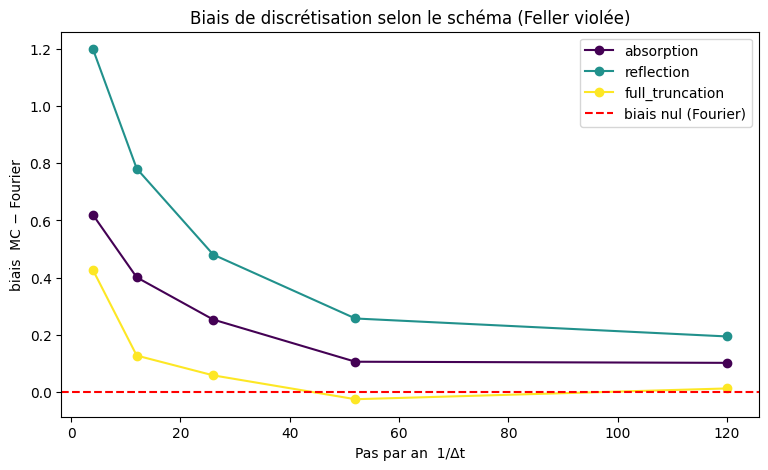

In [89]:
# Biais des 3 schémas vs pas de temps (N grand, mêmes pas).
N_bias = 100_000
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("viridis")
schemes = list(EulerDiscretizationConvention)
for i, conv in enumerate(schemes):
    biases = []
    for mdt in dts:
        model = example_heston.discretize(CIRDiscretizationSchemeEuler(conv), max_dt=mdt)
        biases.append(model.simulate(ref_call, N_bias, rng=np.random.default_rng(42)).mean() - px_fourier)
    ax.plot(1/dts, biases, "o-", color=cmap(i / (len(schemes) - 1)), label=conv.value)

ax.axhline(0, color="red", ls="--", label="biais nul (Fourier)")
ax.set_xlabel("Pas par an  1/Δt"); ax.set_ylabel("biais  MC − Fourier")
ax.set_title("Biais de discrétisation selon le schéma (Feller violée)")
ax.legend()
plt.show()


### **3.5 Limite de Carr-Madan : plancher numérique & explosion de moment**

Le pricing Fourier n'est pas exact à la précision machine partout. Deux limites, importantes dès qu'on
s'en sert pour **construire une surface** (notebook 06) :

**(a) Un plancher numérique sur les prix profondément OTM.** Le prix désamorti
$C(k)=e^{-\alpha k}\,\widehat{c}(k)$ est dominé, pour $k$ grand (option très OTM), par l'**arrondi** de la
quadrature : il **plafonne** à un petit résidu (parfois **négatif**) au lieu de tendre vers 0. La **vol
implicite inversée devient alors aberrante** dès que le vrai prix passe sous ce plancher — typiquement
dans les **ailes à courte maturité** (options à plusieurs $\sigma\sqrt{T}$ de la monnaie).

Le levier pour abaisser ce plancher est l'**amortissement $\alpha$** — *pas* la taille de grille $n$
(qui n'améliore que la précision *ATM*) :

*(Cellules encapsulées dans des fonctions : elles ne modifient aucune variable du notebook.)*

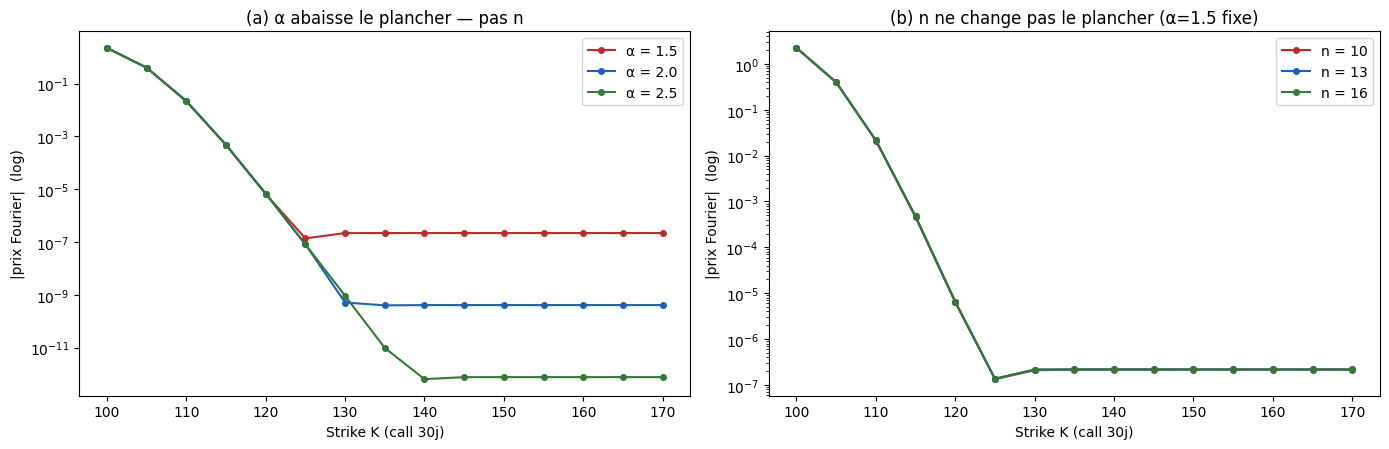

Smile 30j sur [100,170] : 11/15 strikes à IV aberrante (prix sous le plancher).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import date, timedelta
from JR_PRICER.market_data.quote import Quote
from JR_PRICER.market_data.underlying import Underlying
from JR_PRICER.utils.day_count import DayCounter
from JR_PRICER.curves.temporal.discount import FlatDiscountCurve
from JR_PRICER.curves.forward.analytic_forward import AnalyticForwardCurve
from JR_PRICER.instruments.derivatives.equity.base import OptionType
from JR_PRICER.instruments.derivatives.equity.european_option import EuropeanOption
from JR_PRICER.pricing.model.heston import HestonModel
from JR_PRICER.pricing.engine.fourier_carr_madan import FourierCarrMadanEngine
from JR_PRICER.pricing.implied_vol_calculator import ImpliedVolCalculator

def _bug2_floor_demo():
    C_MKT, C_IMP, C_ACC = '#C62828', '#1565C0', '#2E7D32'
    REF = date(2024, 1, 15); DC = DayCounter('act/365')
    disc = FlatDiscountCurve(0.03, DC, REF); spot = Quote(100.0, name='EQ')
    fwd = AnalyticForwardCurve(spot, disc, dividend_yield=0.0)
    und = Underlying('EQ', spot, fwd, vol_provider=None)
    heston = HestonModel(discount_curve=disc, kappa=1.5, theta=0.04, sigma_v=0.5, rho=-0.7, v0=0.035)
    ivc = ImpliedVolCalculator(disc)
    d30 = REF + timedelta(days=30)
    Kw = np.linspace(100, 170, 15)
    cw = [EuropeanOption(und, float(K), REF, d30, OptionType.CALL) for K in Kw]

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
    for a, c in [(1.5, C_MKT), (2.0, C_IMP), (2.5, C_ACC)]:
        px = np.abs(np.asarray(FourierCarrMadanEngine(n=12, alpha=a).price(cw, heston)))
        ax[0].semilogy(Kw, np.maximum(px, 1e-18), 'o-', color=c, ms=4, label=f'α = {a}')
    ax[0].set_xlabel('Strike K (call 30j)'); ax[0].set_ylabel('|prix Fourier|  (log)')
    ax[0].set_title('(a) α abaisse le plancher — pas n'); ax[0].legend()
    for n_, c in [(10, C_MKT), (13, C_IMP), (16, C_ACC)]:
        px = np.abs(np.asarray(FourierCarrMadanEngine(n=n_, alpha=1.5).price(cw, heston)))
        ax[1].semilogy(Kw, np.maximum(px, 1e-18), 'o-', color=c, ms=4, label=f'n = {n_}')
    ax[1].set_xlabel('Strike K (call 30j)'); ax[1].set_ylabel('|prix Fourier|  (log)')
    ax[1].set_title('(b) n ne change pas le plancher (α=1.5 fixe)'); ax[1].legend()
    plt.tight_layout(); plt.show()

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        iv = np.asarray(ivc.calculate_implied_vol(cw, FourierCarrMadanEngine(n=12).price(cw, heston)))
    bad = int(np.sum((iv < 0.01) | ~np.isfinite(iv)))
    print(f"Smile 30j sur [100,170] : {bad}/{len(Kw)} strikes à IV aberrante (prix sous le plancher).")

_bug2_floor_demo()

**(b) L'explosion de moment : $\alpha$ ne peut pas être arbitrairement grand.** Carr-Madan évalue
la fonction caractéristique en argument **complexe** $\phi\big(u-(\alpha+1)i\big)$, finie seulement dans
une **bande** du plan complexe (Heston a une *explosion de moment* : le moment d'ordre $\alpha+1$ devient
infini au-delà d'une maturité critique, d'autant plus tôt que $\rho$, $\sigma_v$, $T$ sont grands). Si
$\alpha$ sort de cette bande, le prix devient **dépendant de $\alpha$** — donc silencieusement **faux**.
On le voit en traçant la vol implicite ATM en fonction de $\alpha$ : plate (correcte) en régime modéré,
mais qui **dérive** en régime extrême.

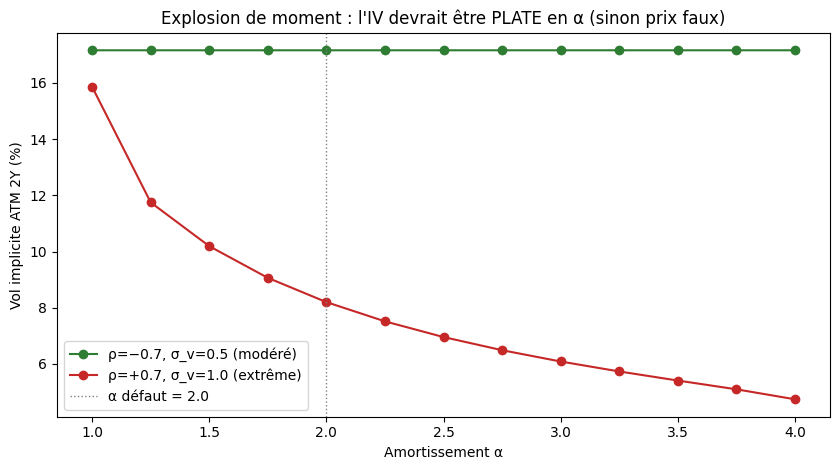

In [2]:
def _bug2_moment_demo():
    C_MKT, C_ACC = '#C62828', '#2E7D32'
    REF = date(2024, 1, 15); DC = DayCounter('act/365')
    disc = FlatDiscountCurve(0.03, DC, REF); spot = Quote(100.0, name='EQ')
    fwd = AnalyticForwardCurve(spot, disc, dividend_yield=0.0)
    und = Underlying('EQ', spot, fwd, vol_provider=None)
    ivc = ImpliedVolCalculator(disc)
    d730 = REF + timedelta(days=730); T2 = DC.year_fraction(REF, d730); F2 = fwd.forward(T2)
    atm2 = EuropeanOption(und, float(F2), REF, d730, OptionType.CALL)
    alphas = np.linspace(1.0, 4.0, 13)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for rho_, sv_, lbl, col in [(-0.7, 0.5, 'ρ=−0.7, σ_v=0.5 (modéré)', C_ACC),
                                (0.7, 1.0, 'ρ=+0.7, σ_v=1.0 (extrême)', C_MKT)]:
        h = HestonModel(discount_curve=disc, kappa=1.5, theta=0.04, sigma_v=sv_, rho=rho_, v0=0.035)
        ivs = []
        for a in alphas:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                px = FourierCarrMadanEngine(n=12, alpha=a).price([atm2], h)[0]
                ivs.append(float(ivc.calculate_implied_vol([atm2], [px])[0]) * 100)
        ax.plot(alphas, ivs, 'o-', color=col, label=lbl)
    ax.axvline(2.0, color='grey', ls=':', lw=1, label='α défaut = 2.0')
    ax.set_xlabel('Amortissement α'); ax.set_ylabel('Vol implicite ATM 2Y (%)')
    ax.set_title("Explosion de moment : l'IV devrait être PLATE en α (sinon prix faux)")
    ax.legend(); plt.tight_layout(); plt.show()

_bug2_moment_demo()

**À retenir.**
- Le **plancher** se pilote par **$\alpha$** (défaut $2.0$ : plancher $\sim 4\!\times\!10^{-10}$, contre
  $\sim 2\!\times\!10^{-7}$ à $\alpha=1.5$), **jamais par $n$**.
- Mais $\alpha$ trop grand ⇒ **explosion de moment** (surtout $\rho$, $\sigma_v$, $T$ élevés) ⇒ prix
  faux : le **baisser** sur ces paramètres extrêmes. Le défaut $2.0$ est un compromis robuste.
- **Conséquence** : les **ailes à courte maturité** d'une surface construite par Fourier sont **peu
  fiables** (options quasi sans valeur, sous le plancher) — on y revient au **notebook 06** (vol locale),
  où l'on reste dans la zone de strikes couverte par le Monte-Carlo.

### **Récapitulatif**

- **Convergence** : le prix MC tend vers le prix Fourier (exact) quand $N \to \infty$.
- **Vitesse** : l'erreur statistique décroît en $1/\sqrt{N}$ (pente $-1/2$ en log-log) — réduire l'erreur d'un facteur 10 coûte 100× plus de trajectoires.
- **Biais de pas** : à $N$ fixé, le biais d'Euler décroît avec le pas $\Delta t$ ($\mathcal{O}(\Delta t)$).
- **Biais de schéma** : sous Feller violée, *full-truncation* est le moins biaisé ; *absorption* et *reflection* le sont davantage.

En pratique : pas fin + full-truncation + $N$ grand. Pour aller plus loin, des schémas d'ordre supérieur (ex. **Andersen QE**) réduisent le biais, et des techniques de réduction de variance (antithétiques, variables de contrôle) réduisent l'erreur statistique.